In [1]:
# import standard python libraries
import matplotlib as mpl
%matplotlib inline
mpl.rcParams['figure.dpi'] = 96
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import os, subprocess
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

In [2]:
# import libraries for biological data analysis
from coolpuppy import coolpup
from coolpuppy.lib import numutils
from coolpuppy.lib.puputils import divide_pups
from coolpuppy import plotpup
import cooler
import bioframe
import cooltools
from cooltools import expected_cis, expected_trans
from cooltools.lib import plotting

In [3]:
resolution=5000
clr_2 = cooler.Cooler(f"/usr/users/papantonis1/aman/microc_data/nadine_macro/RBP1-MNase-R1-filtered.mcool::resolutions/{resolution}")
clr_1 = cooler.Cooler(f"/usr/users/papantonis1/aman/microc_data/nadine_macro/ctrl-MNase-R1-filtered.mcool::resolutions/{resolution}")

In [4]:
expected = expected_cis(
    clr_1,
    ignore_diags=0,
    nproc=8,
    chunksize=1000000)

INFO:root:creating a Pool of 8 workers


In [5]:
sites = pd.read_csv(
    "/usr/users/papantonis1/aman/stripecaller_ctrl_all_anchors.bed",
    sep="\t", header=None, usecols=[0,1,2],
    names=["chrom","start","end"], comment="#"
)

# this is needed 

sites["name"] = "."
sites["score"] = 0
sites["strand"] = "."

sites

,chrom,start,end,name,score,strand
0,chr1,5510000,5515000,.,0,.
1,chr1,5510000,5515000,.,0,.
2,chr1,5610000,5660000,.,0,.
3,chr1,5730000,5775000,.,0,.
4,chr1,6490000,6495000,.,0,.
...,...,...,...,...,...,...
9427,chrX,150775000,150780000,.,0,.
9428,chrX,151055000,151100000,.,0,.
9429,chrX,151080000,151085000,.,0,.
9430,chrX,151715000,151760000,.,0,.


In [8]:
pup = coolpup.pileup(
    clr_1, sites, features_format='bed',
    expected_df=expected, by_strand=False,
    mindist=100_000, maxdist=1_000_000,
    flank=300_000, nproc=16, store_stripes=True
)


INFO:coolpuppy:('chr16', 'chr16'): 768
INFO:coolpuppy:('chr15', 'chr15'): 1154
INFO:coolpuppy:('chr14', 'chr14'): 1237
INFO:coolpuppy:('chr13', 'chr13'): 924
INFO:coolpuppy:('chr9', 'chr9'): 2226
INFO:coolpuppy:('chr10', 'chr10'): 1539
INFO:coolpuppy:('chr12', 'chr12'): 2319
INFO:coolpuppy:('chr8', 'chr8'): 2161
INFO:coolpuppy:('chr11', 'chr11'): 2929
INFO:coolpuppy:('chr7', 'chr7'): 2241
INFO:coolpuppy:('chr5', 'chr5'): 2583
INFO:coolpuppy:('chr4', 'chr4'): 2508
INFO:coolpuppy:('chr6', 'chr6'): 3362
INFO:coolpuppy:('chr3', 'chr3'): 3301
INFO:coolpuppy:('chr1', 'chr1'): 3875
INFO:coolpuppy:('chr2', 'chr2'): 4752
INFO:coolpuppy:('chr19', 'chr19'): 499
INFO:coolpuppy:('chr17', 'chr17'): 1251
INFO:coolpuppy:('chr21', 'chr21'): 193
INFO:coolpuppy:('chr18', 'chr18'): 1014
INFO:coolpuppy:('chr22', 'chr22'): 307
INFO:coolpuppy:('chr20', 'chr20'): 1098
INFO:coolpuppy:('chrX', 'chrX'): 149
INFO:coolpuppy:Total number of piled up windows: 42390


In [14]:
pup

,group,data,n,num,coordinates,horizontal_stripe,vertical_stripe,clr,resolution,flank,...,flip_negative_strand,ignore_diags,store_stripes,nproc,ignore_group_order,by_window,by_strand,by_distance,groupby,cooler
0,all,"[[0.9497740077242971, 0.9618959473956809, 0.95...",42390,"[[40459, 40460, 40518, 40472, 40537, 40534, 40...","[[chr1, 5510000, 5515000, chr1, 5610000, 56600...","[[nan, nan, nan, nan, nan, nan, nan, nan, nan,...","[[nan, nan, nan, nan, nan, nan, nan, nan, nan,...",/usr/users/papantonis1/aman/microc_data/nadine...,5000,300000,...,False,2,True,16,False,False,False,False,[],ctrl-MNase-R1-filtered


In [15]:
pup.columns

Index(['group', 'data', 'n', 'num', 'coordinates', 'horizontal_stripe',
       'vertical_stripe', 'clr', 'resolution', 'flank', 'rescale_flank',
       'chroms', 'minshift', 'maxshift', 'nshifts', 'trans', 'mindist',
       'maxdist', 'local', 'subset', 'seed', 'clr_weight_name', 'expected',
       'expected_value_col', 'ooe', 'control', 'pad_bins', 'coverage_norm',
       'rescale', 'rescale_size', 'flip_negative_strand', 'ignore_diags',
       'store_stripes', 'nproc', 'ignore_group_order', 'by_window',
       'by_strand', 'by_distance', 'groupby', 'cooler'],
      dtype='object')

In [21]:
# keep required columns; put a scalar ('group') before array cols
p2 = pup[["n", "group", "horizontal_stripe", "vertical_stripe",
          "flank", "resolution", "data"]].copy()

from coolpuppy import plotpup
import seaborn as sns
sns.set(font_scale=1.3, style="ticks")

plotpup.plot_stripes(
    p2,
    rows="group",                 # explicit faceting
    stripe="vertical_stripe",
    stripe_sort="sum",
    vmax=10, height=4,
    plot_ticks=True
)


KeyError: 'coordinates'

In [3]:
resolution=100000
clr_2 = cooler.Cooler(f"/usr/users/papantonis1/aman/microc_data/nadine_macro/RBP1-MNase-R1-filtered.mcool::resolutions/{resolution}")
clr_1 = cooler.Cooler(f"/usr/users/papantonis1/aman/microc_data/nadine_macro/ctrl-MNase-R1-filtered.mcool::resolutions/{resolution}")

In [25]:
if not os.path.isfile('./hg38.fa'):
    subprocess.call('wget -q https://hgdownload.cse.ucsc.edu/goldenpath/hg38/bigZips/hg38.fa.gz', shell=True)
    subprocess.call('gunzip hg38.fa.gz', shell=True)
hg38_genome = bioframe.load_fasta('./hg38.fa');
bins = clr_1.bins()[:]
gc_cov = bioframe.frac_gc(bins[['chrom', 'start', 'end']], hg38_genome)

In [27]:
# Calculate eigenvectors at 100 kb resolution using cooltools, phased by GC coverage
cis_eigs = cooltools.eigs_cis(clr_1, 
                              gc_cov, 
                              n_eigs=3)
eigenvector_track = cis_eigs[1][['chrom','start','end','E1']]
# Extract and merge A compartments (eigenvector E1>0)
A_compartments = bioframe.merge(eigenvector_track[eigenvector_track["E1"] > 0], 
                                min_dist=0)

In [28]:
trans_expected = expected_trans(
    clr_1, 
    chunksize=1000000, nproc=16)

INFO:root:creating a Pool of 16 workers


In [30]:
pup = coolpup.pileup(clr_1, A_compartments, features_format='bed',
                     expected_df=trans_expected, trans=True,
                     rescale=True, rescale_flank=1, rescale_size=99, nproc=20)

/usr/users/papantonis1/anaconda3/envs/cool_notebook/lib/python3.10/site-packages/coolpuppy/coolpup.py:2156: UserWarning: Ignoring maxdist when using trans
  CC = CoordCreator(
INFO:coolpuppy:Rescaling with rescale_flank = 1 to 99x99 pixels
INFO:coolpuppy:('chr3', 'chr19'): 1092
INFO:coolpuppy:('chr3', 'chrY'): 1428
INFO:coolpuppy:('chr1', 'chr22'): 1330
INFO:coolpuppy:('chr1', 'chr17'): 2185
INFO:coolpuppy:('chr2', 'chr20'): 2550
INFO:coolpuppy:('chr2', 'chr15'): 2754
INFO:coolpuppy:('chr3', 'chr14'): 2940
INFO:coolpuppy:('chr4', 'chr14'): 3325
INFO:coolpuppy:('chr3', 'chr20'): 2100
INFO:coolpuppy:('chr3', 'chr9'): 4200
INFO:coolpuppy:('chr4', 'chr9'): 4750
INFO:coolpuppy:('chr2', 'chr21'): 2040
INFO:coolpuppy:('chr3', 'chr21'): 1680
INFO:coolpuppy:('chr3', 'chr15'): 2268
INFO:coolpuppy:('chr1', 'chr18'): 2850
INFO:coolpuppy:('chr2', 'chr10'): 5508
INFO:coolpuppy:('chr1', 'chr12'): 5700
INFO:coolpuppy:('chr4', 'chr15'): 2565
INFO:coolpuppy:('chr2', 'chr22'): 1428
INFO:coolpuppy:('chr3'

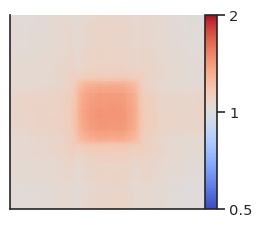

In [31]:
fg = plotpup.plot(pup,
                  score=False, cmap='coolwarm', scale='log', 
                  sym=True, vmax=2, height=3)

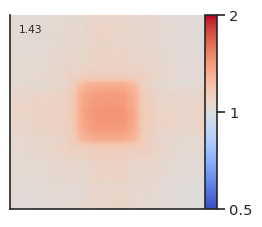

In [32]:
fg = plotpup.plot(
    pup,
    score=True,
    cmap='coolwarm',
    scale='log',
    sym=True,
    vmax=2,
    height=3
)


INFO:root:creating a Pool of 24 workers
/usr/users/papantonis1/anaconda3/envs/cool_notebook/lib/python3.10/site-packages/coolpuppy/coolpup.py:2156: UserWarning: Ignoring maxdist when using trans
  CC = CoordCreator(
INFO:coolpuppy:Rescaling with rescale_flank = 1 to 99x99 pixels
INFO:coolpuppy:('chr3', 'chr19'): 814
INFO:coolpuppy:('chr2', 'chr19'): 869
INFO:coolpuppy:('chr3', 'chr22'): 1184
INFO:coolpuppy:('chr2', 'chr22'): 1264
INFO:coolpuppy:('chr1', 'chr17'): 1633
INFO:coolpuppy:('chr1', 'chr20'): 2130
INFO:coolpuppy:('chr1', 'chr14'): 2272
INFO:coolpuppy:('chr3', 'chr13'): 2664
INFO:coolpuppy:('chr2', 'chr13'): 2844
INFO:coolpuppy:('chr3', 'chr20'): 2220
INFO:coolpuppy:('chr3', 'chr16'): 3182
INFO:coolpuppy:('chr1', 'chr11'): 3053
INFO:coolpuppy:('chr2', 'chr20'): 2370
INFO:coolpuppy:('chr2', 'chr16'): 3397
INFO:coolpuppy:('chr1', 'chr21'): 1278
INFO:coolpuppy:('chr3', 'chr10'): 3700
INFO:coolpuppy:('chr2', 'chr10'): 3950
INFO:coolpuppy:('chr1', 'chr18'): 2414
INFO:coolpuppy:('chr

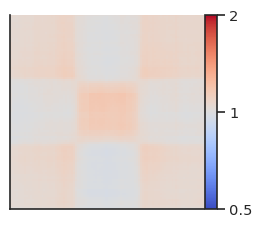

In [5]:
resolution=100000
clr_2 = cooler.Cooler(f"/usr/users/papantonis1/aman/microc_data/nadine_macro/RBP1-MNase-R1-filtered.mcool::resolutions/{resolution}")
clr_1 = cooler.Cooler(f"/usr/users/papantonis1/aman/microc_data/nadine_macro/ctrl-MNase-R1-filtered.mcool::resolutions/{resolution}")
if not os.path.isfile('./hg38.fa'):
    subprocess.call('wget -q https://hgdownload.cse.ucsc.edu/goldenpath/hg38/bigZips/hg38.fa.gz', shell=True)
    subprocess.call('gunzip hg38.fa.gz', shell=True)
hg38_genome = bioframe.load_fasta('./hg38.fa');
bins = clr_2.bins()[:]
gc_cov = bioframe.frac_gc(bins[['chrom', 'start', 'end']], hg38_genome)
# Calculate eigenvectors at 100 kb resolution using cooltools, phased by GC coverage
cis_eigs = cooltools.eigs_cis(clr_2, 
                              gc_cov, 
                              n_eigs=3
                              )
eigenvector_track = cis_eigs[1][['chrom','start','end','E1']]
# Extract and merge B compartments (eigenvector E1 < 0)
B_compartments = bioframe.merge(
    eigenvector_track[eigenvector_track["E1"] < 0],
    min_dist=0
)
trans_expected = expected_trans(
    clr_2, 
    chunksize=1000000, nproc=24)
pup = coolpup.pileup(clr_2, B_compartments, features_format='bed',
                     expected_df=trans_expected, trans=True,
                     rescale=True, rescale_flank=1, rescale_size=99, nproc=24)
fg = plotpup.plot(pup,
                  score=False, cmap='coolwarm', scale='log', 
                  sym=True, vmax=2, height=3)

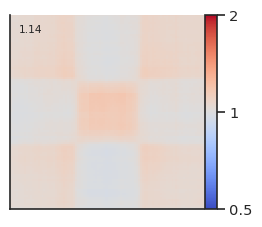

In [6]:
fg = plotpup.plot(
    pup,
    score=True,
    cmap='coolwarm',
    scale='log',
    sym=True,
    vmax=2,
    height=3
)

/usr/users/papantonis1/anaconda3/envs/cool_notebook/lib/python3.10/site-packages/coolpuppy/coolpup.py:2156: UserWarning: Ignoring maxdist when using trans
  CC = CoordCreator(


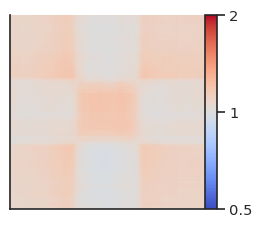

In [11]:
resolution=100000
clr_2 = cooler.Cooler(f"/usr/users/papantonis1/aman/microc_data/nadine_macro/RBP1-MNase-R1-filtered.mcool::resolutions/{resolution}")
clr_1 = cooler.Cooler(f"/usr/users/papantonis1/aman/microc_data/nadine_macro/ctrl-MNase-R1-filtered.mcool::resolutions/{resolution}")
if not os.path.isfile('./hg38.fa'):
    subprocess.call('wget -q https://hgdownload.cse.ucsc.edu/goldenpath/hg38/bigZips/hg38.fa.gz', shell=True)
    subprocess.call('gunzip hg38.fa.gz', shell=True)
hg38_genome = bioframe.load_fasta('./hg38.fa');
bins = clr_1.bins()[:]
gc_cov = bioframe.frac_gc(bins[['chrom', 'start', 'end']], hg38_genome)
# Calculate eigenvectors at 100 kb resolution using cooltools, phased by GC coverage
cis_eigs = cooltools.eigs_cis(clr_1, 
                              gc_cov, 
                              n_eigs=3
                              )
eigenvector_track = cis_eigs[1][['chrom','start','end','E1']]
# Extract and merge B compartments (eigenvector E1 < 0)
B_compartments = bioframe.merge(
    eigenvector_track[eigenvector_track["E1"] < 0],
    min_dist=0
)
trans_expected = expected_trans(
    clr_1, 
    chunksize=1000000, nproc=24)
pup = coolpup.pileup(clr_1, B_compartments, features_format='bed',
                     expected_df=trans_expected, trans=True,
                     rescale=True, rescale_flank=1, rescale_size=99, nproc=24)
fg = plotpup.plot(pup,
                  score=False, cmap='coolwarm', scale='log', 
                  sym=True, vmax=2, height=3)

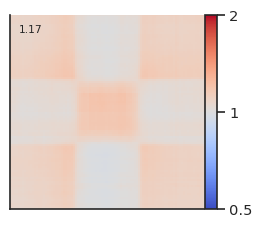

In [12]:
fg = plotpup.plot(
    pup,
    score=True,
    cmap='coolwarm',
    scale='log',
    sym=True,
    vmax=2,
    height=3
)

In [ ]:
# ctrl A compartment with phasing ensured

/usr/users/papantonis1/anaconda3/envs/cool_notebook/lib/python3.10/site-packages/coolpuppy/coolpup.py:2156: UserWarning: Ignoring maxdist when using trans
  CC = CoordCreator(


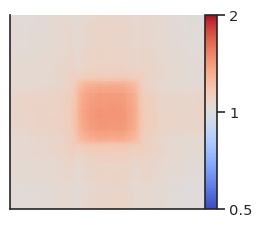

In [13]:
resolution = 100_000
clr_2 = cooler.Cooler(f"/usr/users/papantonis1/aman/microc_data/nadine_macro/RBP1-MNase-R1-filtered.mcool::resolutions/{resolution}")
clr_1 = cooler.Cooler(f"/usr/users/papantonis1/aman/microc_data/nadine_macro/ctrl-MNase-R1-filtered.mcool::resolutions/{resolution}")

# GC track for phasing
bins = clr_1.bins()[:][['chrom','start','end']]
hg38_genome = bioframe.load_fasta('./hg38.fa')
gc_cov = bioframe.frac_gc(bins, hg38_genome)  # Series aligned to bins

# Eigenvectors, correctly phased by GC
cis_eigs = cooltools.eigs_cis(
    clr_1,
    n_eigs=3,
    phasing_track=gc_cov  # ensures E1 positively correlates with GC (≈ A)
)
eigs_df = cis_eigs[1][['chrom','start','end','E1']].copy()

# --- A compartments: E1 > 0 ---
A_bins = eigs_df.loc[np.isfinite(eigs_df['E1']) & (eigs_df['E1'] > 0), ['chrom','start','end']]
A_compartments = bioframe.merge(A_bins, min_dist=0)

# Expected and pileup over A compartments (trans)
trans_exp = expected_trans(clr_1, chunksize=1_000_000, nproc=24)
pup_A = coolpup.pileup(
    clr_1, A_compartments, features_format='bed',
    expected_df=trans_exp, trans=True,
    rescale=True, rescale_flank=1, rescale_size=99, nproc=24
)
fig_A = plotpup.plot(pup_A, score=False, cmap='coolwarm', scale='log', sym=True, vmax=2, height=3)

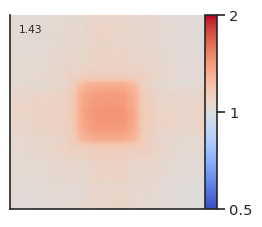

In [14]:
fg = plotpup.plot(
    pup_A,
    score=True,
    cmap='coolwarm',
    scale='log',
    sym=True,
    vmax=2,
    height=3
)

/usr/users/papantonis1/anaconda3/envs/cool_notebook/lib/python3.10/site-packages/coolpuppy/coolpup.py:2156: UserWarning: Ignoring maxdist when using trans
  CC = CoordCreator(


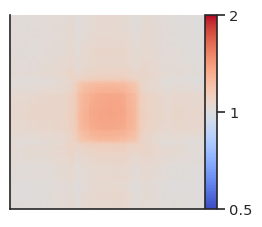

In [15]:
resolution = 100_000
clr_2 = cooler.Cooler(f"/usr/users/papantonis1/aman/microc_data/nadine_macro/RBP1-MNase-R1-filtered.mcool::resolutions/{resolution}")
clr_1 = cooler.Cooler(f"/usr/users/papantonis1/aman/microc_data/nadine_macro/ctrl-MNase-R1-filtered.mcool::resolutions/{resolution}")

# GC track for phasing
bins = clr_2.bins()[:][['chrom','start','end']]
hg38_genome = bioframe.load_fasta('./hg38.fa')
gc_cov = bioframe.frac_gc(bins, hg38_genome)  # Series aligned to bins

# Eigenvectors, correctly phased by GC
cis_eigs = cooltools.eigs_cis(
    clr_2,
    n_eigs=3,
    phasing_track=gc_cov  # ensures E1 positively correlates with GC (≈ A)
)
eigs_df = cis_eigs[1][['chrom','start','end','E1']].copy()

# --- A compartments: E1 > 0 ---
A_bins = eigs_df.loc[np.isfinite(eigs_df['E1']) & (eigs_df['E1'] > 0), ['chrom','start','end']]
A_compartments = bioframe.merge(A_bins, min_dist=0)

# Expected and pileup over A compartments (trans)
trans_exp = expected_trans(clr_2, chunksize=1_000_000, nproc=24)
pup_A = coolpup.pileup(
    clr_2, A_compartments, features_format='bed',
    expected_df=trans_exp, trans=True,
    rescale=True, rescale_flank=1, rescale_size=99, nproc=24
)
fig_A = plotpup.plot(pup_A, score=False, cmap='coolwarm', scale='log', sym=True, vmax=2, height=3)

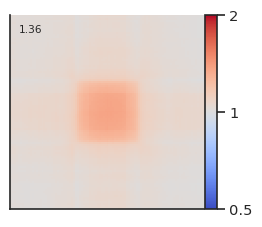

In [16]:
fg = plotpup.plot(
    pup_A,
    score=True,
    cmap='coolwarm',
    scale='log',
    sym=True,
    vmax=2,
    height=3
)